# Find lines with the matched filter

This tutorial runs on the CASA-free test fixture: jackknifed noise of the `line13_line9` mock with two Gaussian lines injected at known positions. `DataHandler(msfile)` reads a measurement set into the same structure.

In [1]:
import tempfile

import numpy as np
from IPython.display import Image

from luv_finder import DataHandler, Gaussian, MatchedFilter, Model
from luv_finder.plotting import response_check, spectrum_check

plots = tempfile.mkdtemp()

## Data

The visibilities are held per (field, spectral window) as a `Chunk`: the weighted visibilities `X = w * V` and their flags per channel and row, and `u`, `v`, time and weight once per row.

In [2]:
data = DataHandler.from_npz("../../../tests/fixtures/line13_line9_small.npz")
(chunk,) = data.chunks
n_chan, n_row = chunk.X.shape
print(f"{n_row} rows x {n_chan} channels, {data.nbytes / 1e6:.1f} MB")

1368 rows x 50 channels, 1.2 MB


## Line 1

Weighted-mean visibility spectra. At the phase centre the offset line averages away; phase-shifted onto its position it appears in the real part, matching the model, while the jackknife stays consistent with zero.

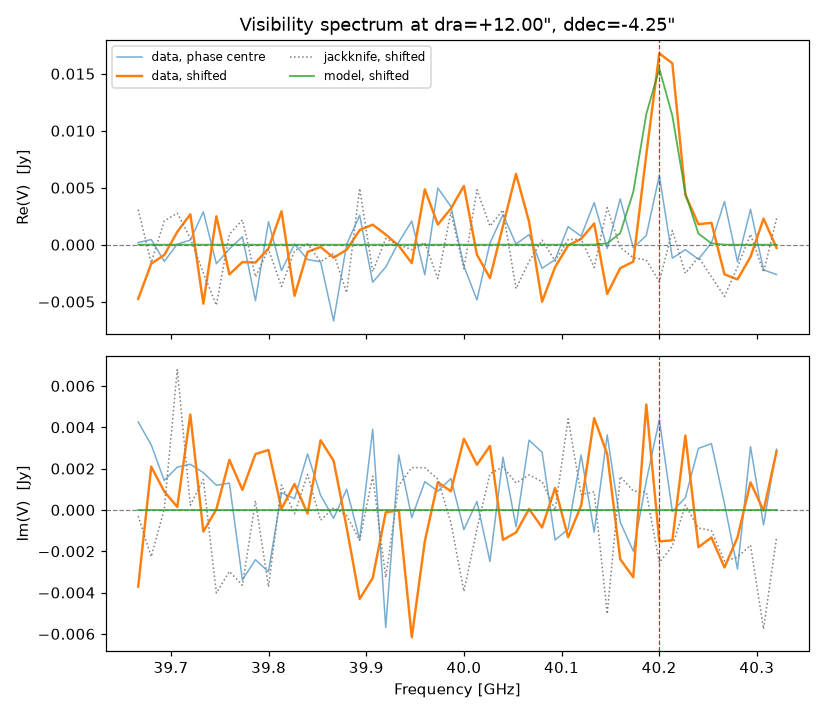

In [3]:
line1 = Gaussian(dra=12.0, ddec=-4.25, total_flux=5.1, bmin=0.33, bmaj=0.33, nu_center=40.2e9, width=300)
Image(spectrum_check(data, 12.0, -4.25, model=line1, plots_dir=plots, name="line1", line_ghz=40.2))

## Line 2

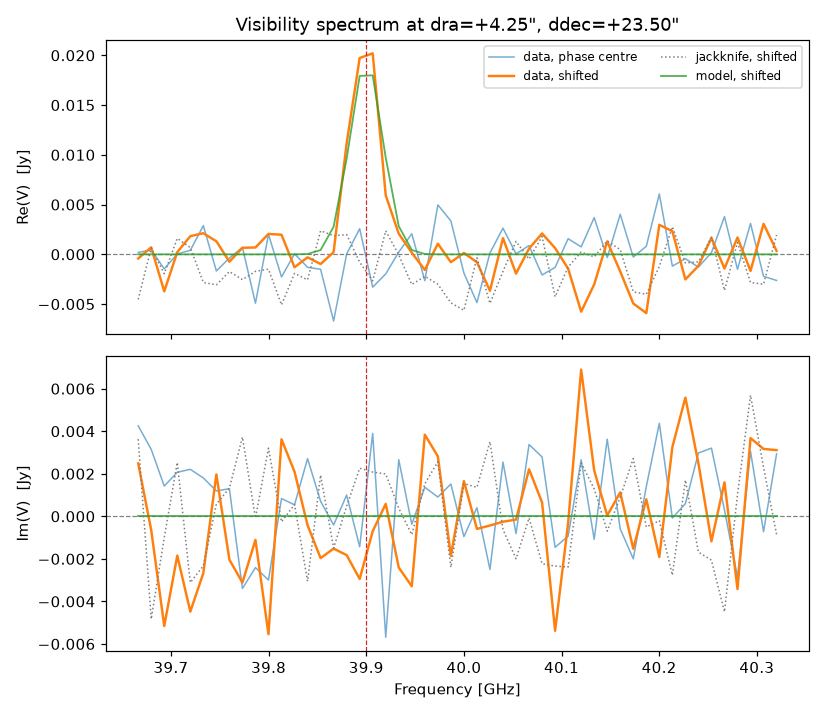

In [4]:
line2 = Gaussian(dra=4.25, ddec=23.5, total_flux=6.4, bmin=0.33, bmaj=0.33, nu_center=39.9e9, width=300)
Image(spectrum_check(data, 4.25, 23.5, model=line2, plots_dir=plots, name="line2", line_ghz=39.9))

## Matched filter

Search both positions with a 300 km/s template. The response is in signal-to-noise units, so each on-source grid point peaks at its line's S/N, and the jackknife shows the noise floor on the same axis.

In [5]:
g = Gaussian()
g.grid = {"dra": [12.0, 4.25], "ddec": [-4.25, 23.5], "bmin": 0.33, "bmaj": 0.33, "width": 300.0}
mod = Model()
mod.addcomponent(g)
mf = MatchedFilter(data, mod)
mf.run(pool=1, jackknife=True)

freqs = mf.frequencies()
for params, response in zip(mf.grid_params, mf.response):
    i = np.argmax(response)
    print(f"dra={params['src_00_dra']:+6.2f} ddec={params['src_00_ddec']:+6.2f}: "
          f"peak S/N {response[i]:5.1f} at {freqs[i]:.3f} GHz")
print(f"jackknife max |S/N| {np.abs(mf.response_jackknife).max():.1f}")

Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

Grid search: 100%|██████████| 4/4 [00:00<00:00, 236.61it/s]

Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

Grid search: 100%|██████████| 4/4 [00:00<00:00, 369.49it/s]

dra=+12.00 ddec= -4.25: peak S/N   9.4 at 40.200 GHz
dra=+12.00 ddec=+23.50: peak S/N   2.7 at 40.254 GHz
dra= +4.25 ddec= -4.25: peak S/N   2.7 at 40.173 GHz
dra= +4.25 ddec=+23.50: peak S/N  12.0 at 39.893 GHz
jackknife max |S/N| 3.4


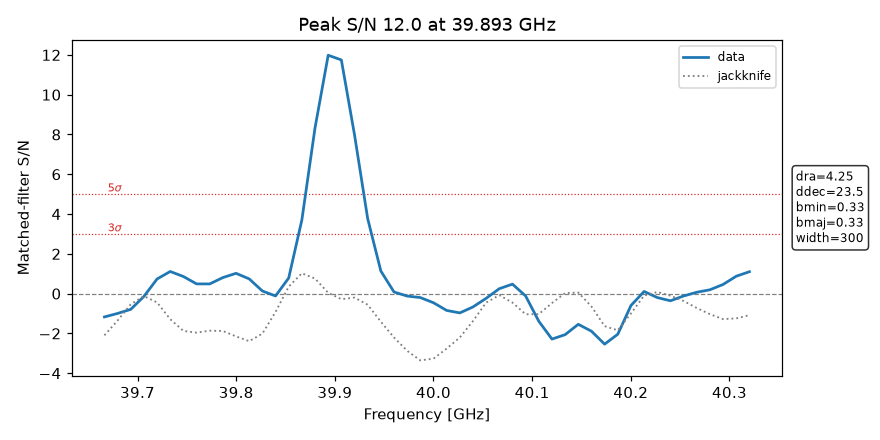

In [6]:
Image(response_check(mf, plots_dir=plots, name="response"))